In [ ]:
# Before making any changes, duplicate this notebook and work on a local version.

# TP 1: Optimization problems and cost functions

**Objective:**
By the end of this lab session, you should be able to:
- Formulate combinatorial optimization problems is python
- Solve some optimization problems using simple methods (such as local, random and exhaustive search)

Especially, we will be interested in implementing problems seen in during the course:
- Max-cut problems
- Ising problems
- Travelling salesman problem
- QUBO problems
- Knapsack problem

Recommended tools and libraries:
- Python (>= 3.10)
- networkx (https://networkx.org/en/)
- sympy (https://www.sympy.org/en/index.html)

Part of the code generated during this session will be reused to create the basis of your optimization library (project that must be finished by 24/03 at midnight CET).


In [ ]:
# Imports used during the lab session
# Networkx is a python package used for the creation and manipulation of graphs
import networkx as nx

# Sympy is a python package used for the creation and manipulation of symbolic expressions
from sympy import *

: 

## 1. The Maxcut problem

The max-cut problem is a problem on graphs where the aim is to split the vertices in two subsets such that the number of edges shared by the two sets is maximized.
For a graph $G = (V, E)$ with $V$ the set of vertices and $E$ the set of edges, the cost function to maximize is the following:
$$-\sum_{(v_i, v_j) \in E} s_{v_i} s_{v_j}$$

with $s_v \in \{-1, +1\}$.

In [ ]:
# TODO 1: Create a class MaxCutProblem that can be instanciated with a networkx graph.
class MaxCutProblem: 
    def __init__(self, graph):
        self.graph = graph
        self._sympy_expr = None

# TODO 2: Create a method to_sympy_expr() that converts the Maxcut graph to a sympy expression if the expression has not yet been computed.
#         Once computed, store it in a class attribute and check if this attribute exists before the computation (it can be costly to do it several times)
#         You can use the sympify function of the sympy library to create the expression
#         See the documentation here: https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html
    def to_sympy_expr():
        if self._sympy_expr is None:
            expr_str = ""
            for u, v in self.graph.edges(data = true):
                weight = data.get("weight", 1)
                term = f"-{weight} * (x_{u} * x_{v})"
                expr_str += term + " " 

            self._sympy_expr = sympify(expr_str.replace(" -", " - " ).replace(" +", " + "))
        return self._sympy_expr


#
# TODO 3: Create a method eval(solution) that evaluates the cost associated to a solution. The solution could be a dictionnary with string keys
# (variables of the cost function) and integer values. You can use the sympy subs method (do not forget to cast your strings to symbols).
    def eval(solution):
        expr = self.to_sympy_expr()
        subs_dict = {symbol}
        

#
# TODO 4: Test your code with a small networkx graph (less than 10 nodes)

Up to now you should already have tested you code. To test it, create a simple networkx instance (for example, the one that was given as example in class:

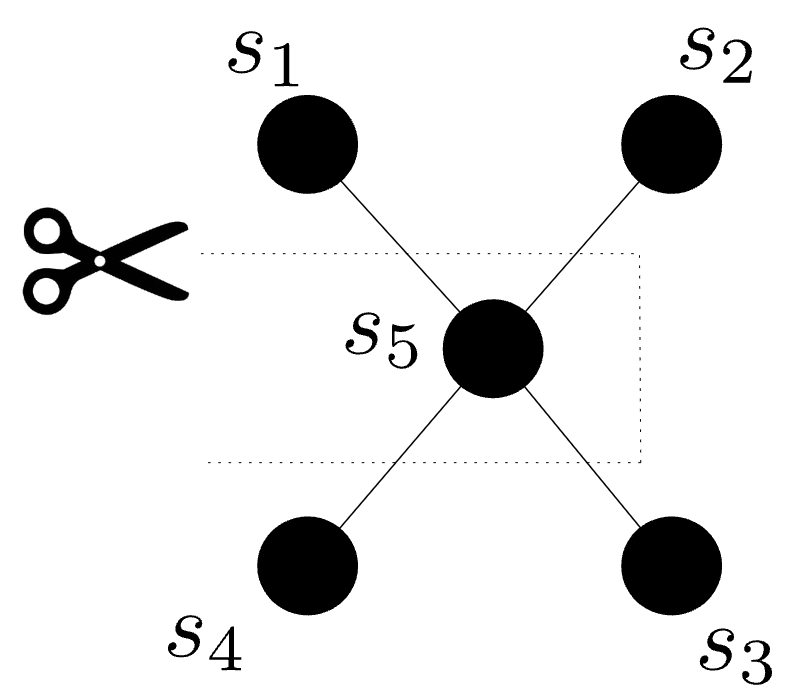




In [ ]:
# Let's now create some fancy display methods in the MaxCutProblem class.
# TODO 5: Create a method display_graph() which displays the graph associated to your instances (nodes and edges)
# TODO 6: Create a method display_solution(solution) which displays the graph nodes with, two colors, one for each possible value of the
# variables of the domain.
# To do this, you can get some inspiration from the code in the documentatio:
# https://networkx.org/documentation/stable/auto_examples/drawing/plot_labels_and_colors.html

Up to now, we only considered the unweighted MaxCut problem. Can you now consider the more general case with a weighted instance. The cost function associated with this kind of instance is:

$$-\sum_{(v_i, v_j) \in E} J_{ij} s_{v_i} s_{v_j}$$

where $J_{ij} \in \mathbb{R}$.

In [ ]:
# TODO 7: Modify your code to make it more general and only consider weighted Maxcut instances. We will consider that the weights of the instances
# are given with the networkx graph instance (via data labels on edges).
# Try your code with a new instance with weights on edges (use the networkx method add_weighted_edges_from to create the instance)

## 2. QUBO (Quadratic Unconstrained Binary optimization) problem

A QUBO problem is represented by either:
- a triangular upper matrix
- a symmetric matrix

The QUBO problem is formally stated as:
$$\min f(Q) = \sum_{i=1}^n\sum_{j=1}^n Q_{i, j} x_i x_j$$

where $Q$ is the matrix and $x_i \in \{0, 1\}$.

In [ ]:
# TODO 8: Create a class QuboProblem that can be instanciated by giving a scipy matrix.
#         Your constructor should check that the matrix is either upper triangular or symmetric (see scipy documentation to check this property)
#         Trigger an exception if it's not the case.
#         For this todo, additionnal imports could be necessary.
import numpy as np
import scipy.sparse as sp


class QuboProblem():
    def __init__(self, M):

        if not (sp.issparse(M) or isinstance(M, np.ndarray)):
            M = np.array(M)

        if self._is_symmetric(M) or self._is_upper_triangular(M):
            self.matrix = M
        else:
            raise Exception("The matrix must be either symmetric or triangular upper.")

    def _is_symmetric(self,M):
        if sp.issparse(M):
            return (M != M.T).nnz == 0
        return np.allclose(M,M.T)

    def _is_triangular_upper(self,M):
        if sp.issparse(M):
            return sp.tril(M, k= -1).nnz == 0
        return np.allclose(M, np.triu(M))
        




: 

In [ ]:
# TODO 9: In the QuboProblem class, create a method to_sympy_expr() that convert the QUBO matrix to a sympy expression.
def to_sympy_expr(self):
    expr = ""
    n_rows, n_cols = self.matrix.shape
    x = symbols(f'x0:{n_rows}')
    terms = []
    if sp.issparse(self.matrix):
        rows, cols, values = sp.find(self.matrix)
        for i, j, v in zip(rows, cols, values):
            terms.append(v*x[i]*x[j])
    else:
        for i in range(n_rows):
            for j in range(n_cols):
                if self.matrix[i,j] != 0:
                    terms.append(self.matrix[i, j] * x[i] * x[j])
    
    self._symply_expr = Add(*terms)
    return self._sympy_expr
# TODO 10: In the QuboProblem, create a method eval(solution) that evaluates the cost of a solution (it could simply trigger a vector-matrix
# multiplication, hence, not using the sympy expression).

def eval(solution):
    

# TODO 11: Create a toy matrix and check that your code is working as expected.

## 3. Ising problems

An Ising problem is represented by a cost function on $n$ variables:

$$\min C_{Ising} = \sum_{i=1}^n w_i s_i + \sum_{i<j} w_{i, j} s_i s_j$$

where $w_i$ and $w_{i, j}$ are the weights of the problem.

In [ ]:
import sympy as sp
import networkx as nx

#TODO 12: Create a class IsingProblem which takes as input either and Ising cost function string or a graph with weights defining an Ising expression

class IsingProblem:
    def __init__(self, string=None, graph=None):
        if string is not None:
            self.expr = sp.sympify(string)
            
        elif graph is not None:
            
            expr = 0
            for u, v, data in graph.edges(data=True):
                weight = data.get('weight', 1.0) 
                s_u = sp.Symbol(str(u))
                s_v = sp.Symbol(str(v))
                expr += weight * s_u * s_v
                
            for node, data in graph.nodes(data=True):
                weight = data.get('weight', 0.0) 
                if weight != 0.0:
                    s_n = sp.Symbol(str(node))
                    expr += weight * s_n
                    
            self.expr = expr
            
        else:
            raise ValueError("Tu dois fournir soit 'cost_string' soit 'graph'.")
            

        self.variables = list(self.expr.free_symbols)

#Create a method to_sympy_expr() that returns the sympy expression
    def to_sympy_expr(self):
        return self.expr

# TODO 13: In the IsingProblem, create a method get_cost(solution) that evaluates the cost of a solution.
    def get_cost(self, solution):
        subs_dict = {}
        for var, val in solution.items():
            if isinstance(var, str):
                subs_dict[sp.Symbol(var)] = val
            else:
                subs_dict[var] = val
        cost = self.expr.subs(subs_dict)
        return float(cost)


# TODO 14: Create a toy example and check that your code is working as expected.

G_test = nx.Graph()
G_test.add_node('s1', weight=-1.0)
G_test.add_node('s2') 
G_test.add_node('s3')
G_test.add_edge('s1', 's2', weight=2.0)
G_test.add_edge('s2', 's3', weight=-1.0)
G_test.add_edge('s1', 's3', weight=1.5)

string_test = "+2*s1*s2 -1*s1 +3*s2*s3 +4*s2 -5*s3*s1+ 8*s3"

mon_probleme_1 = IsingProblem(string= string_test)
mon_probleme_2 = IsingProblem(graph= G_test)

ma_solution = {
    's1': 1,
    's2': -1,
    's3': 1
}

print(f"1.   La formule est {mon_probleme_1.to_sympy_expr()} et contient {mon_probleme_1.variables}")
print(f"Pour la configuration {ma_solution},le coût total calculé est : {mon_probleme_1.get_cost(ma_solution)} ")

print(f"2.   La formule est {mon_probleme_2.to_sympy_expr()} et contient {mon_probleme_2.variables}")
print(f"Pour la configuration {ma_solution},le coût total calculé est : {mon_probleme_2.get_cost(ma_solution)} ")



In [ ]:
# TODO 15 : Create a conversion method qubo_to_ising that convert a QuboProblem to an IsingProblem. (see lecture notes)
# TODO 16 : Create a conversion method ising_to_qubo that convert an IsingProblem to as QuboProblem. (see lecture notes)

## 4. Knapsack problem

Given a set of items, each with a weight and a value, determine which items to include in the collection so that the total weight is less than or equal to a given limit and the total value is as large as possible.

Search space:
$$\mathcal{X}=\{0, 1\}^n$$

Objective function:
$$\max \sum_i x_i p_i , x_i \in \{0, 1\}$$

Constraints:
$$\text{s.t. }\sum_i w_i x_i < W$$

with $p_i$ the price of the object and $w_i$ its weight


In [ ]:
# TODO 17: Create a new class KnapsackProblem which can be used to create the Knapsack problem.
#         Add a method is_feasible checking that a solution is feasible before evaluating its cost.
#         Add a method eval which returns the solution to a given instance
# Create a toy instance and check that your code is working as expected.

## 5. Travelling Salesman Problem (TSP)

Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city?

Search space (set of all the permutations):
$$\mathcal{X} = S_n$$

$$S_n = \{[\text{city}_1, \text{city}_2, \text{city}_3, ... \text{city}_n], [\text{city}_2, \text{city}_1, \text{city}_3, ... \text{city}_n] ...\}$$


In [ ]:
# TODO 18: Create a new class TspProblem which can be used to create an instance of the TSP problem.
#         Add a method eval which returns the solution to a given instance
#         Add a method display_solution(solution) which displays the solution to the TSP problem
# Create a toy instance and check that your code is working as expected.

In [ ]:
# TODO 19: Create an exhaustive search function that tries any possible combination to a specific Problem.
#         To do that, for each class KnapsackProblem, TspProblem, IsingProblem, QuboProblem, MaxCutProblem,
#         create a method generate_complete_search_space that generate the complete search space.
#         The exhaustive function should then call the method generate_complete_search_space of the problem and try find the best solution calling
#           eval() of each problem.
#         You should be able to use this function for both maximization and minimization problems

# Can you find some ways to parallelize the execution of this algorithm ?
# Code another function that parallelize the execution of the code

In [ ]:
# TODO 20: Create a random search function that randomly try some configuration of the problem
#       This method should record the current best solution to the problem and return it at the end of the process

In [ ]:
# TODO 21: Create a local search function that starts from a random initial solution and pick each time a neighbor configuration.
#         You can code this method only for the Qubo problem
#         For the Qubo problem create a method gen_neighbor_sol which randomly generate a neighbor solution of a current solution.
#         For example, a neighbor solution of {x1: 0, x2: 1, x3: 1} is a solution 1 bit flip away (for example: {x1: 0, x2: 1, x3: 0})

In [ ]:
# TODO 22: Export your current code to a local project.
# You should have the following directories:
#   - Problem (store all your classes of problems)
#     - ...
#     -
#     - Converter.py (functions that convert a problem to another one)
#   - Algorithm
#     - Classical_Algorithm
#       - Random_search.py
#       - Exhaustive_search.py
#       - Local_search.py

# To ease the imports you could create a file __init.py__
# See documentation there: https://docs.python.org/3/tutorial/modules.html

# Create a private github repo for your project and invite your teacher in the project:
#   Valentin-Teacher-ESILV (valentin.gilbert@ext.devinci.fr)
# In the readme of the project, add the name of the students working on the project (maximum of 2)

In [ ]:
# TODO 23 (Bonus): Try to combine the random and local search algorithm
# Add this new algorithm in your project under the name